# Pseudobulk method benchmark

**Environment:** `clamp-analyses`

Scores all matrix factorization methods against ground-truth cell-type fractions across all pseudobulk datasets. Loads B matrices from `output/01_model_building/05_pseudobulk/` and truth fractions from `data/pseudobulk/`. Uses a greedy one-to-one LV → cell-type assignment (`oneToOneMask`) and reports the maximum Pearson correlation per cell type. Outputs written to `output/03_model_biology/02_pseudobulk/`.

## Libraries

In [1]:
library(data.table)
library(dplyr)
library(tidyr)
library(ggplot2)
library(ggpubr)
library(patchwork)
library(yaml)
library(here)

set.seed(123)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:data.table’:

    between, first, last


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




here() starts at /home/msubirana/Documents/pivlab/clamp-analyses



## Configuration

In [2]:
DATASETS <- c("Brain_Mathys2023", "Brain_Xiong2023",
              "CRC_Pelka2021", "PBMC_1k1k", "PBMC_Perez2022")

DATA_DIR <- here("data", "pseudobulk")
MOD_ROOT <- here("output", "01_model_building", "05_pseudobulk")
OUT_DIR  <- here("output", "03_model_biology", "02_pseudobulk")
dir.create(OUT_DIR, showWarnings = FALSE, recursive = TRUE)

# Display name -> B.csv path relative to <MOD_ROOT>/<dataset>/
METHODS <- list(
  CLAMPbase  = "CLAMPbase/B.csv",
  CLAMPfull  = "CLAMPfull/B.csv",
  PLIER      = "PLIER/B.csv",
  PCA        = "PCA/B.csv",
  NMF        = "NMF/B.csv",
  ICA        = "ICA/B.csv",
  Flashier   = "flashier/B.csv",
  `MOFA-FLEX` = "MOFA_FLEX_PRIOR/B_matrix.csv",
  GSSig      = "GSS/B.csv"
)

# Cell type display labels (short code -> full name for plots)
ct_labels_df <- read.csv(here("data", "pseudobulk", "cell_type_labels.csv"),
                         stringsAsFactors = FALSE)
CT_LABELS    <- setNames(ct_labels_df$label, ct_labels_df$cell_type)
ct_label     <- function(x) ifelse(x %in% names(CT_LABELS), CT_LABELS[x], x)

## Scoring helpers

In [3]:
# Greedy one-to-one assignment: each LV -> at most one cell type.
# cc: n_LVs x n_cell_types correlation matrix.
# Returns a masked matrix where each row and column has at most one non-zero.
oneToOneMask <- function(cc) {
  mask <- matrix(0, nrow(cc), ncol(cc), dimnames = dimnames(cc))
  cc_work <- cc
  while (any(!is.na(cc_work) & !is.nan(cc_work))) {
    best <- which(cc_work == max(cc_work, na.rm = TRUE), arr.ind = TRUE)
    if (nrow(best) == 0) break
    r <- best[1, 1]; col <- best[1, 2]
    mask[r, col]    <- cc_work[r, col]
    cc_work[r, ]    <- NA   # LV r used
    cc_work[, col]  <- NA   # cell type col used
  }
  mask
}

# Score an LV matrix (samples x LVs) against a truth matrix (samples x cell_types).
# Returns a named numeric vector: max correlation per cell type after one-to-one assignment.
score_per_ct <- function(fac, truth, ct_names) {
  shared <- intersect(rownames(fac), rownames(truth))
  if (length(shared) == 0) return(setNames(rep(NA_real_, length(ct_names)), ct_names))
  fac_s   <- fac[shared, , drop = FALSE]
  truth_s <- truth[shared, , drop = FALSE]

  fac_s <- fac_s[, apply(fac_s, 2, var, na.rm = TRUE) > 0, drop = FALSE]
  if (ncol(fac_s) == 0) return(setNames(rep(NA_real_, length(ct_names)), ct_names))

  cc  <- cor(fac_s, truth_s, method = "pearson", use = "pairwise.complete.obs")
  cc  <- oneToOneMask(cc)
  v   <- apply(cc, 2, max)
  v[!is.finite(v) | v <= -1] <- NA_real_
  setNames(v, ct_names)
}

# Same assignment as score_per_ct but also returns the LV name mapped to each cell type.
# Returns data.frame(cell_type, LV, cor) — one row per assigned cell type.
lv_per_ct <- function(fac, truth, ct_names) {
  shared <- intersect(rownames(fac), rownames(truth))
  if (length(shared) == 0) return(NULL)
  fac_s   <- fac[shared, , drop = FALSE]
  truth_s <- truth[shared, , drop = FALSE]
  fac_s   <- fac_s[, apply(fac_s, 2, var, na.rm = TRUE) > 0, drop = FALSE]
  if (ncol(fac_s) == 0) return(NULL)

  cc   <- cor(fac_s, truth_s, method = "pearson", use = "pairwise.complete.obs")
  mask <- oneToOneMask(cc)

  do.call(rbind, lapply(ct_names, function(ct) {
    if (!ct %in% colnames(mask)) return(NULL)
    col_vals <- mask[, ct]
    assigned <- which(col_vals != 0)
    if (length(assigned) == 0) return(NULL)
    data.frame(
      cell_type = ct,
      LV        = rownames(mask)[assigned[1]],
      cor       = col_vals[assigned[1]],
      stringsAsFactors = FALSE
    )
  }))
}

# Read B.csv -> samples x LVs (transpose from stored k x samples).
# suppressWarnings: fread warns about missing row-name header, which is expected.
read_B <- function(path) {
  dt  <- suppressWarnings(fread(path))
  mat <- as.matrix(dt[, -1, with = FALSE])
  storage.mode(mat) <- "numeric"
  rownames(mat) <- dt[[1]]
  t(mat)  # samples x LVs
}

# Read truth CSV -> samples x cell_types
read_truth <- function(path) {
  dt  <- suppressWarnings(fread(path))
  mat <- as.matrix(dt[, -1, with = FALSE])
  storage.mode(mat) <- "numeric"
  rownames(mat) <- dt[[1]]
  mat
}

## Score all methods across all datasets

In [4]:
long_rows   <- list()
assign_rows <- list()   # CLAMPfull LV -> cell-type assignments

for (ds in DATASETS) {
  message("\n========== ", ds, " ==========")
  ds_dir <- file.path(MOD_ROOT, ds)

  # Load truth fractions
  p0_path <- file.path(DATA_DIR, ds, "truthFrac_v0.csv")
  if (!file.exists(p0_path)) {
    message("  Truth file missing for ", ds, "; skipping.")
    next
  }
  p0    <- read_truth(p0_path)
  ct_v0 <- colnames(p0)
  cat("  truth: v0=", length(ct_v0), "types\n")

  for (meth in names(METHODS)) {
    b_path <- file.path(ds_dir, METHODS[[meth]])
    if (!file.exists(b_path)) {
      message("  ", meth, " B.csv not found — skipping.")
      next
    }

    fac <- tryCatch(read_B(b_path), error = function(e) {
      message("  ERROR reading ", meth, ": ", conditionMessage(e)); NULL
    })
    if (is.null(fac)) next
    cat("  ", meth, " B: ", nrow(fac), "samples x", ncol(fac), "LVs\n")

    # Score against v0
    cv0 <- score_per_ct(fac, p0, ct_v0)
    long_rows <- c(long_rows, list(data.table(
      dataset   = ds, method = meth, truth = "v0",
      cell_type = names(cv0), cor = unname(cv0)
    )))

    # Also capture which LV was assigned to each cell type for CLAMPfull
    if (meth == "CLAMPfull") {
      assigns <- lv_per_ct(fac, p0, ct_v0)
      if (!is.null(assigns)) {
        assigns$dataset <- ds
        assign_rows <- c(assign_rows, list(as.data.table(assigns)))
      }
    }
  }
}

long           <- rbindlist(long_rows,   fill = TRUE)
lv_assignments <- rbindlist(assign_rows, fill = TRUE)
cat("\nLong table rows:", nrow(long), "\n")
cat("CLAMPfull LV assignments:", nrow(lv_assignments), "\n")
head(long)


========== Brain_Mathys2023 ==========



  truth: v0= 7 types
   CLAMPbase  B:  80 samples x 19 LVs
   CLAMPfull  B:  80 samples x 19 LVs
   PLIER  B:  80 samples x 19 LVs
   PCA  B:  80 samples x 19 LVs
   NMF  B:  80 samples x 19 LVs
   ICA  B:  80 samples x 19 LVs
   Flashier  B:  80 samples x 19 LVs
   MOFA-FLEX  B:  80 samples x 1489 LVs
   GSSig  B:  80 samples x 5 LVs



========== Brain_Xiong2023 ==========



  truth: v0= 7 types
   CLAMPbase  B:  74 samples x 18 LVs
   CLAMPfull  B:  74 samples x 18 LVs
   PLIER  B:  74 samples x 18 LVs
   PCA  B:  74 samples x 18 LVs
   NMF  B:  74 samples x 18 LVs
   ICA  B:  74 samples x 18 LVs
   Flashier  B:  74 samples x 18 LVs
   MOFA-FLEX  B:  74 samples x 1479 LVs
   GSSig  B:  74 samples x 4 LVs



========== CRC_Pelka2021 ==========



...


========== PBMC_1k1k ==========



  truth: v0= 9 types
   CLAMPbase  B:  776 samples x 96 LVs
   CLAMPfull  B:  776 samples x 96 LVs
   PLIER  B:  776 samples x 96 LVs
   PCA  B:  776 samples x 96 LVs
   NMF  B:  776 samples x 96 LVs
   ICA  B:  776 samples x 96 LVs
   Flashier  B:  776 samples x 96 LVs
   MOFA-FLEX  B:  776 samples x 1258 LVs
   GSSig  B:  776 samples x 24 LVs



========== PBMC_Perez2022 ==========



  truth: v0= 4 types
   CLAMPbase  B:  209 samples x 52 LVs
   CLAMPfull  B:  209 samples x 52 LVs
   PLIER  B:  209 samples x 52 LVs
   PCA  B:  209 samples x 52 LVs
   NMF  B:  209 samples x 52 LVs
   ICA  B:  209 samples x 52 LVs
   Flashier  B:  209 samples x 52 LVs
   MOFA-FLEX  B:  209 samples x 1214 LVs
   GSSig  B:  209 samples x 13 LVs

Long table rows: 315 
CLAMPfull LV assignments: 35 


dataset,method,truth,cell_type,cor
<chr>,<chr>,<chr>,<chr>,<dbl>
Brain_Mathys2023,CLAMPbase,v0,Ast,0.9209964
Brain_Mathys2023,CLAMPbase,v0,Exc,0.6287725
Brain_Mathys2023,CLAMPbase,v0,Inh,0.8384232
Brain_Mathys2023,CLAMPbase,v0,Mic,0.9747729
Brain_Mathys2023,CLAMPbase,v0,Oli,0.9561039
Brain_Mathys2023,CLAMPbase,v0,Opc,0.4711528


## Summary table

In [5]:
METHOD_LEVELS <- c("CLAMPbase", "CLAMPfull", "PLIER", "PCA", "NMF", "ICA",
                   "Flashier", "MOFA-FLEX", "GSSig")
long[, method := factor(method, levels = intersect(METHOD_LEVELS, unique(method)))]

summary_dt <- long[, .(
  mean_cor   = mean(cor,   na.rm = TRUE),
  median_cor = median(cor, na.rm = TRUE),
  n_ct       = .N
), by = .(dataset, method, truth)]
setorder(summary_dt, dataset, truth, -mean_cor)

cat("\n--- per-method summary ---\n")
print(summary_dt)

# Save
fwrite(long,           file.path(OUT_DIR, "benchmark_long.csv"))
fwrite(summary_dt,     file.path(OUT_DIR, "benchmark_summary.csv"))
fwrite(lv_assignments, file.path(OUT_DIR, "clampfull_lv_assignments.csv"))
cat("\nSaved to", OUT_DIR, "\n")
cat("CLAMPfull assignments preview:\n")
print(head(lv_assignments, 10))


--- per-method summary ---
             dataset    method  truth  mean_cor median_cor  n_ct
              <char>    <fctr> <char>     <num>      <num> <int>
 1: Brain_Mathys2023 CLAMPbase     v0 0.7240400 0.83842319     7
 2: Brain_Mathys2023 CLAMPfull     v0 0.7196917 0.81557986     7
 3: Brain_Mathys2023     PLIER     v0 0.6927530 0.77440777     7
 4: Brain_Mathys2023  Flashier     v0 0.5358397 0.52533047     7
 5: Brain_Mathys2023       NMF     v0 0.5197706 0.48358174     7
 6: Brain_Mathys2023       PCA     v0 0.4940760 0.48901962     7
 7: Brain_Mathys2023       ICA     v0 0.4105732 0.35160155     7
 8: Brain_Mathys2023 MOFA-FLEX     v0 0.3419949 0.33500672     7
 9: Brain_Mathys2023     GSSig     v0 0.2276379 0.09258128     7
10:  Brain_Xiong2023 CLAMPfull     v0 0.7225356 0.72772950     7
11:  Brain_Xiong2023 CLAMPbase     v0 0.6694332 0.70492437     7
12:  Brain_Xiong2023     PLIER     v0 0.6518692 0.67858399     7
13:  Brain_Xiong2023  Flashier     v0 0.6042748 0.72465694    

## Panel data export (fig5)

In [ ]:
FIG5_DIR <- here("output", "99_panels", "fig5", "fig5")
dir.create(FIG5_DIR, recursive = TRUE, showWarnings = FALSE)
fwrite(long, file.path(FIG5_DIR, "benchmark_long.csv"))
cat("fig5 panel data saved to:", FIG5_DIR, "\n")

## Plots

Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 5 rows containing missing values or values outside the scale range
(`geom_point()`).”


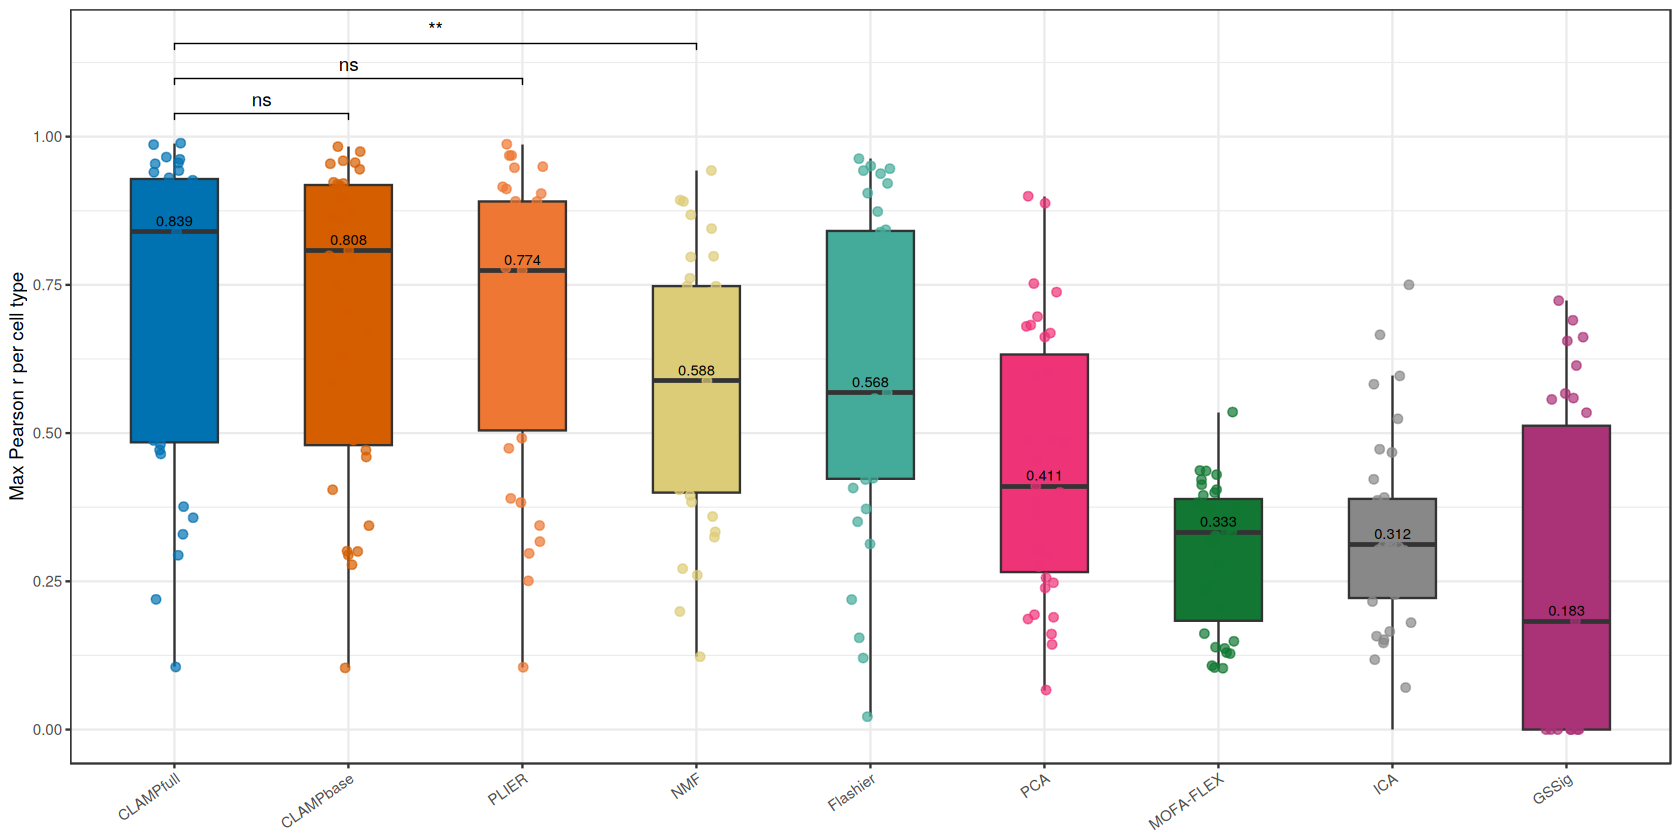

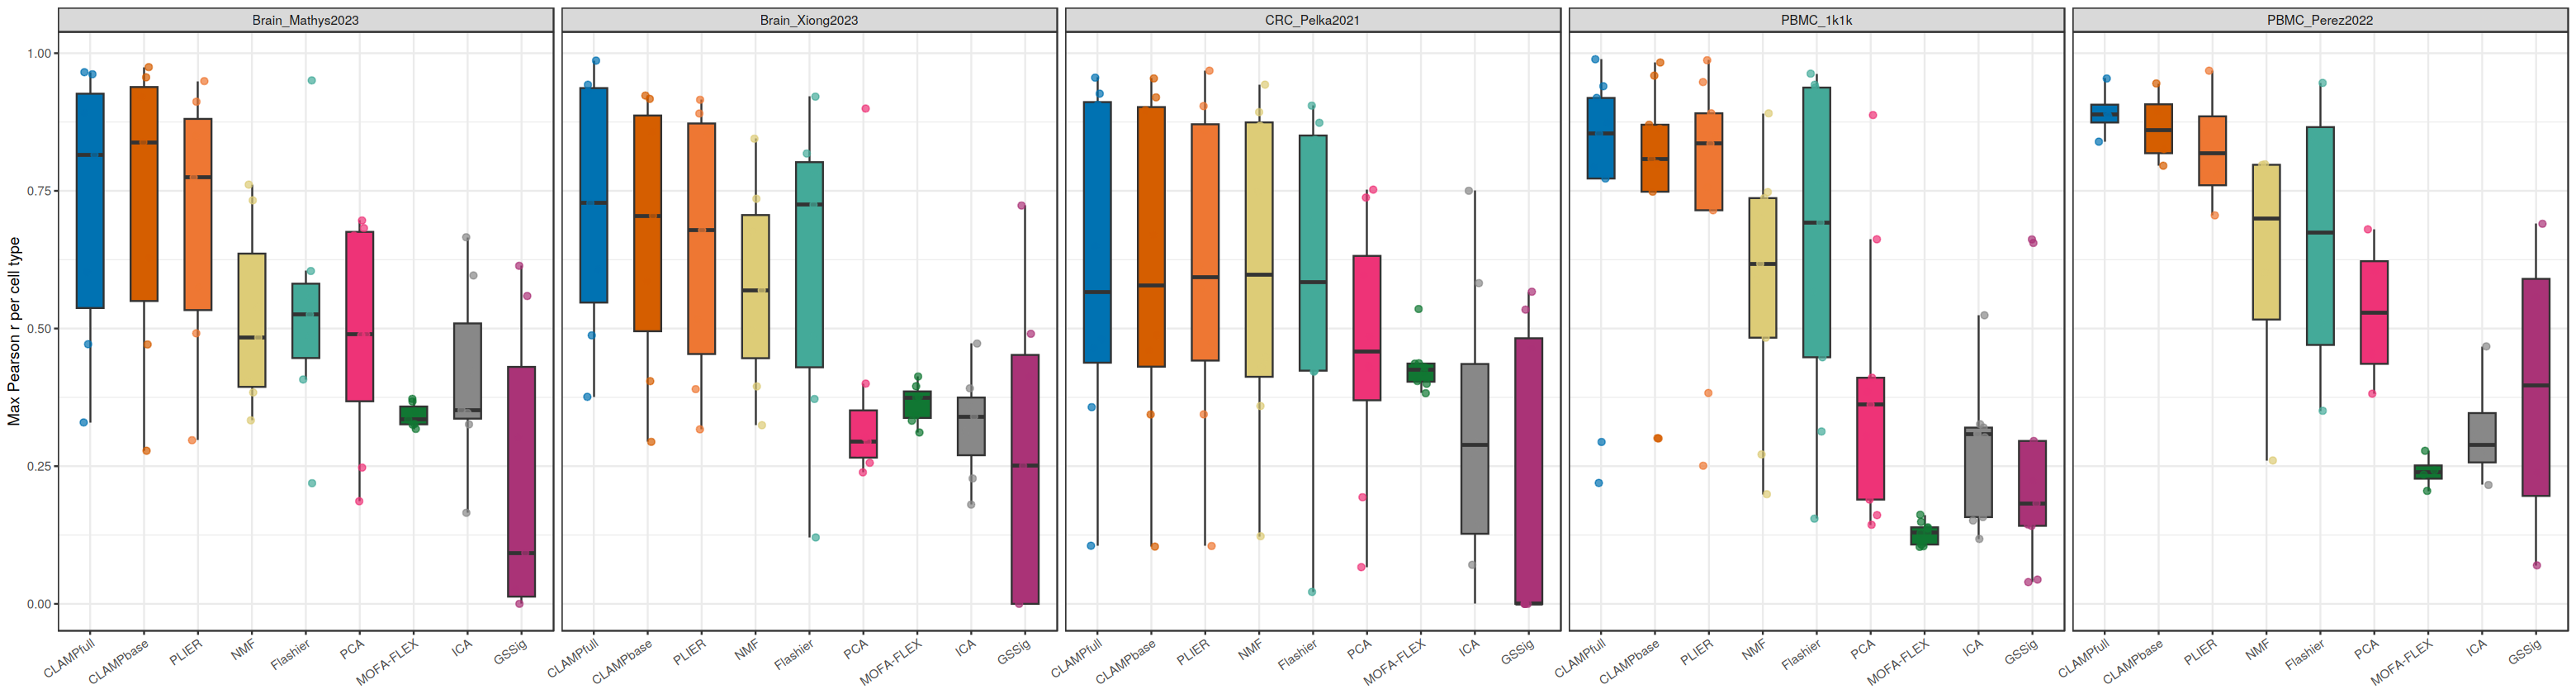

In [6]:
# Read method colors from project config.yaml
cfg           <- yaml::read_yaml(here("config.yaml"))
METHOD_COLORS <- unlist(cfg$MODEL_COLORS)[names(METHODS)]

# Global method order by median per-cell-type cor (descending)
long_box <- long[truth == "v0" & !is.na(cor)]
med_order <- long_box[, .(med = median(cor, na.rm = TRUE)), by = method]
setorder(med_order, -med)
method_order <- as.character(med_order$method)
long_box[, method := factor(method, levels = method_order)]

long[, method := factor(method, levels = method_order)]
sum_v0 <- summary_dt[truth == "v0"]
sum_v0[, method := factor(method, levels = intersect(method_order, unique(as.character(method))))]

# Compare CLAMPfull only against the 3 closest competitors (top methods by median cor)
other_methods <- setdiff(method_order, "CLAMPfull")
comparisons   <- lapply(other_methods[1:3], function(m) c("CLAMPfull", m))

box_theme <- theme_bw(base_size = 11) +
    theme(legend.position = "none",
          axis.text.x = element_text(angle = 35, hjust = 1))

# 1. Global boxplot — each dot = one cell type in one dataset
options(repr.plot.width = 14, repr.plot.height = 7)
p_box <- ggplot(long_box, aes(method, cor, fill = method)) +
    geom_boxplot(outlier.shape = NA, width = 0.5) +
    geom_jitter(aes(color = method), width = 0.12, size = 2, alpha = 0.7,
                show.legend = FALSE) +
    scale_fill_manual(values  = METHOD_COLORS) +
    scale_color_manual(values = METHOD_COLORS) +
    scale_y_continuous(breaks = seq(0, 1, 0.25), limits = c(0, NA)) +
    stat_compare_means(comparisons = comparisons, method = "wilcox.test",
                       label = "p.signif", tip.length = 0.01, step.increase = 0.06) +
    stat_summary(fun = median, geom = "text",
                 aes(label = sprintf("%.3f", after_stat(y))),
                 vjust = -0.5, size = 3, color = "black") +
    box_theme +
    labs(x = NULL, y = "Max Pearson r per cell type")
print(p_box)

# 2. Per-dataset boxplots — same style, one facet per dataset
options(repr.plot.width = 26, repr.plot.height = 7)
p_ds_box <- ggplot(long_box, aes(method, cor, fill = method)) +
    geom_boxplot(outlier.shape = NA, width = 0.5) +
    geom_jitter(aes(color = method), width = 0.12, size = 1.8, alpha = 0.7,
                show.legend = FALSE) +
    scale_fill_manual(values  = METHOD_COLORS) +
    scale_color_manual(values = METHOD_COLORS) +
    scale_y_continuous(breaks = seq(0, 1, 0.25), limits = c(0, NA)) +
    facet_wrap(~ dataset, nrow = 1, scales = "fixed") +
    box_theme +
    theme(strip.text = element_text(size = 9)) +
    labs(x = NULL, y = "Max Pearson r per cell type")
print(p_ds_box)

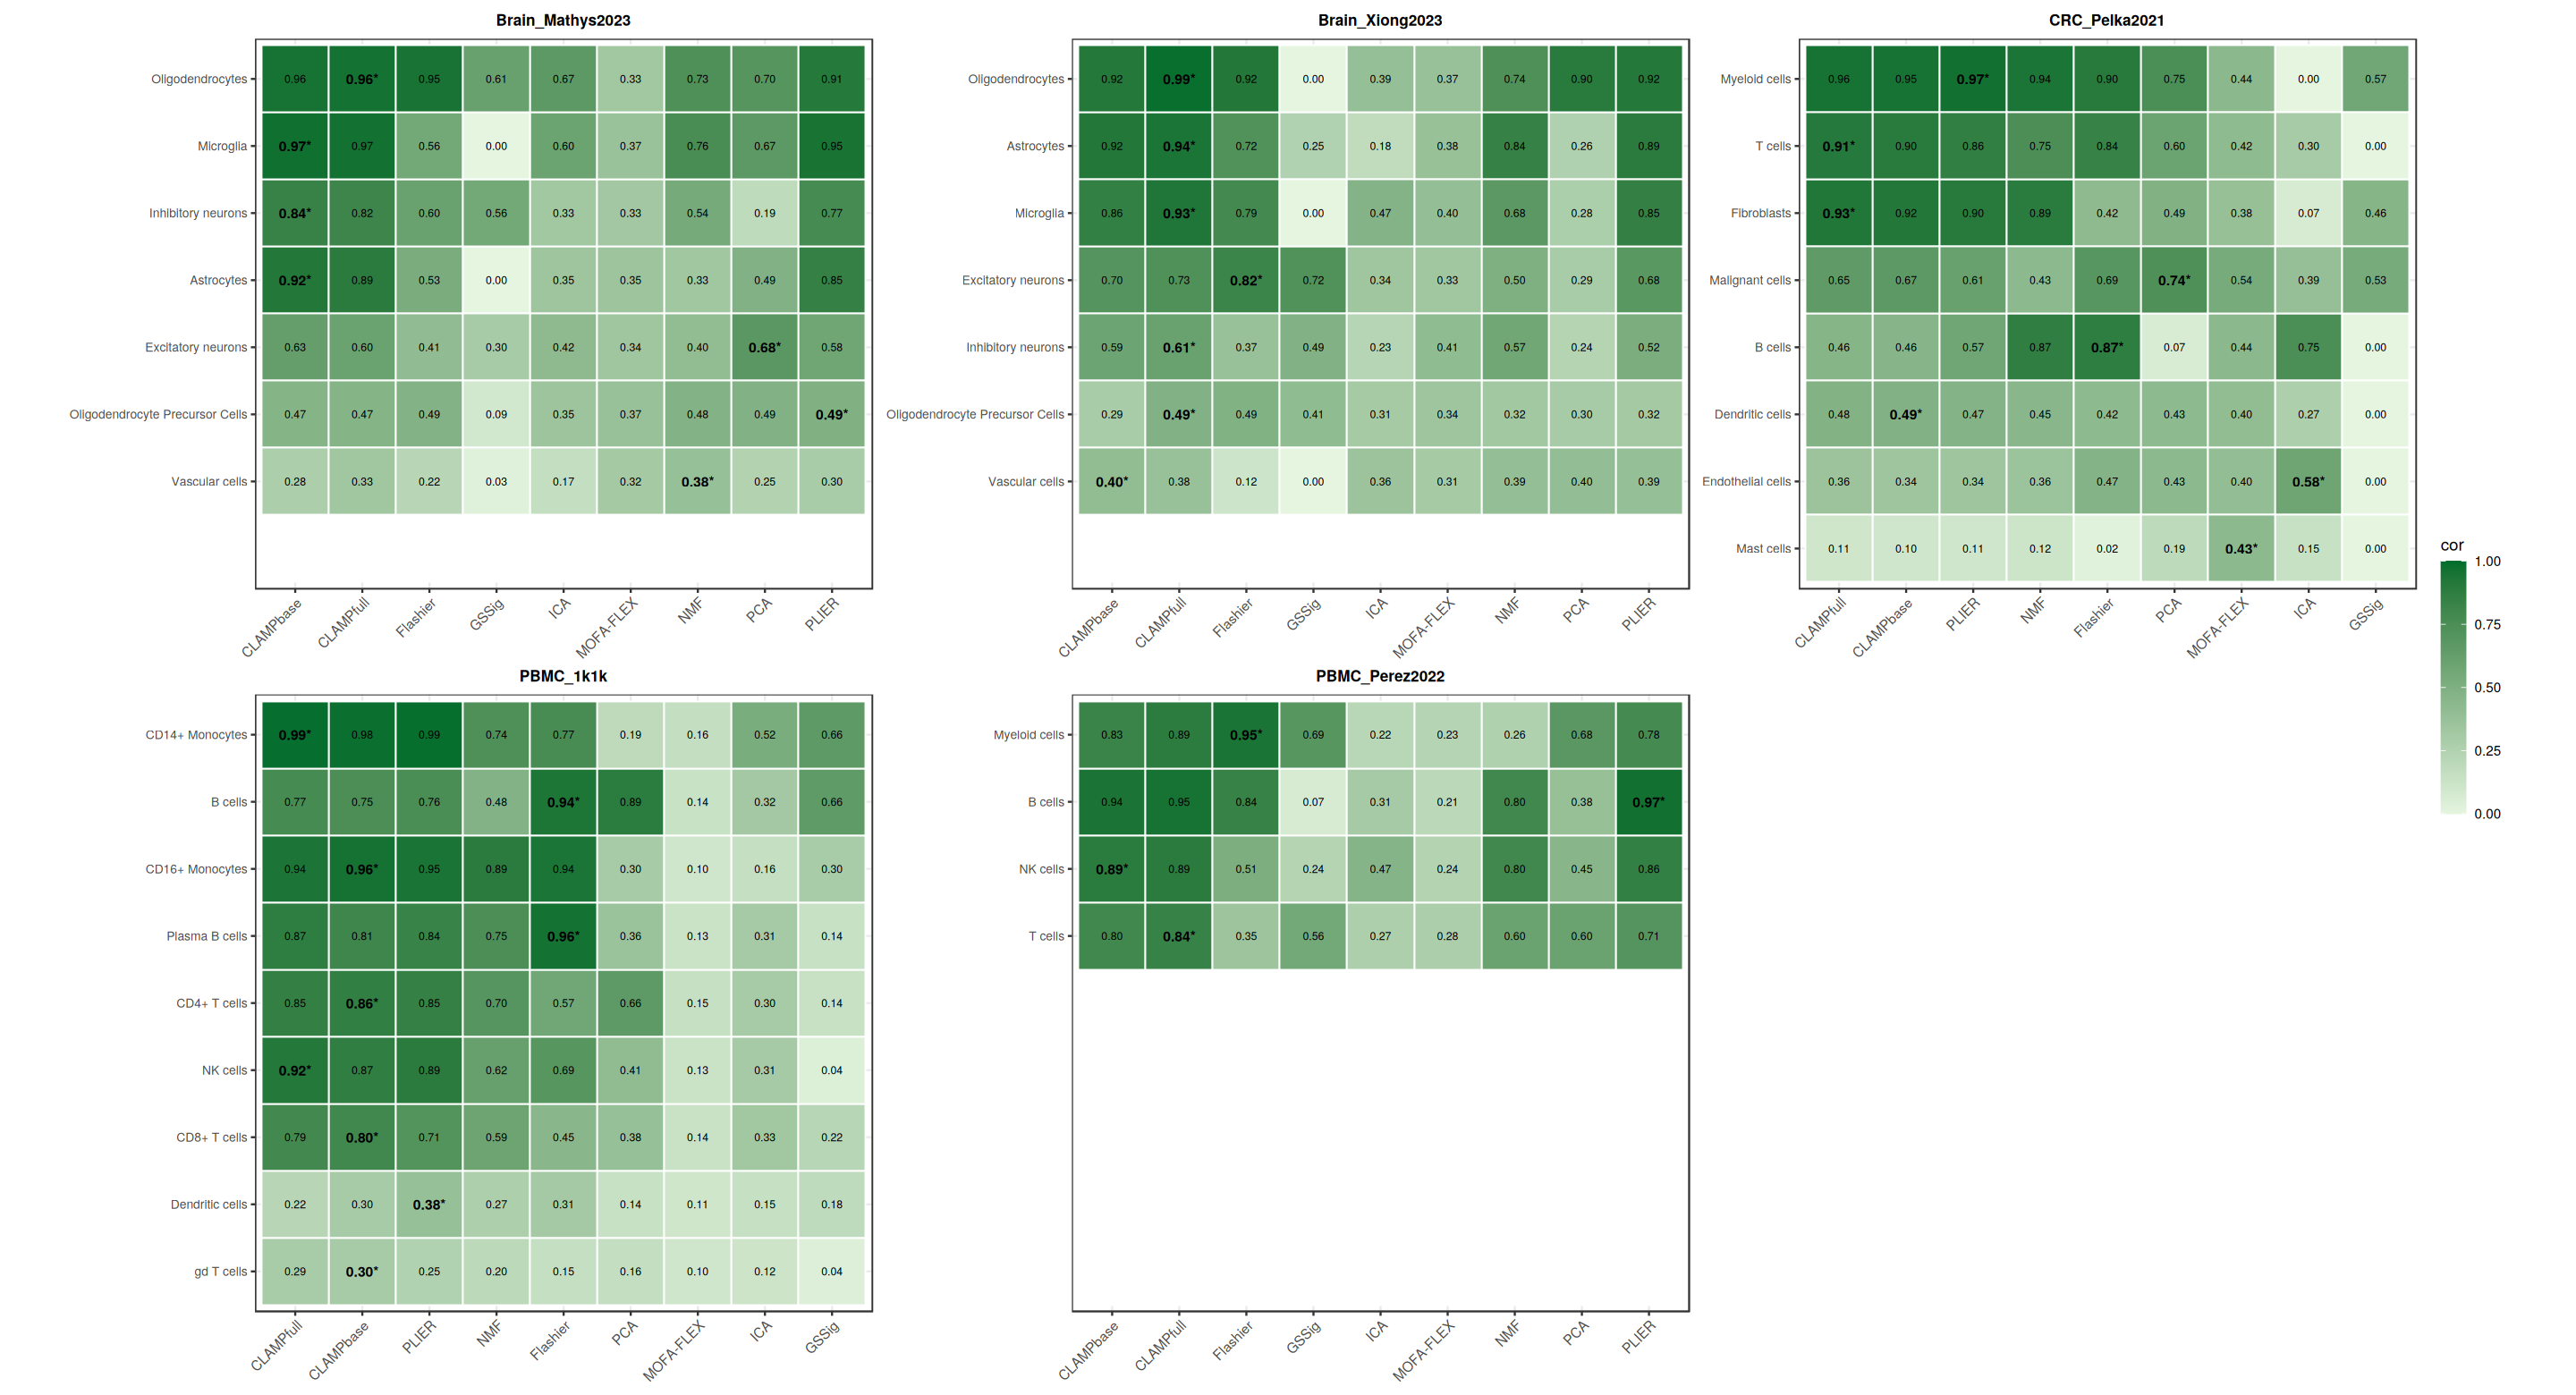

In [7]:
options(repr.plot.width = 24, repr.plot.height = 13)

d_hm <- long[, .(mean_cor = mean(cor, na.rm = TRUE)), by = .(dataset, method, cell_type)]
d_hm[, method := factor(method, levels = method_order)]

# Per-dataset rank prefix so free_y panels sort highest at top
ct_rank <- d_hm[, .(m = mean(mean_cor, na.rm = TRUE)), by = .(dataset, cell_type)]
ct_rank[, rank := frank(m, ties.method = "first"), by = dataset]  # rank 1 = lowest = bottom
ct_rank[, y_label := sprintf("%02d_%s", rank, cell_type)]
d_hm <- merge(d_hm, ct_rank[, .(dataset, cell_type, y_label)], by = c("dataset", "cell_type"))

# Flag best method(s) per (dataset, cell_type) — tie-aware (rounded to 3 dp)
d_hm[, max_cor := max(mean_cor, na.rm = TRUE), by = .(dataset, y_label)]
d_hm[, is_best := !is.na(mean_cor) & round(mean_cor, 3) >= round(max_cor, 3)]

# For each layout row (ncol=3), pad shorter panels with invisible rows at the bottom
# so all panels in the same row reach the same height — content aligns at the top.
NCOL_HM <- 3
n_cts <- setNames(
    sapply(DATASETS, function(ds) length(unique(d_hm$y_label[d_hm$dataset == ds]))),
    DATASETS
)
row_max_ct <- sapply(seq_along(DATASETS), function(i) {
    row   <- ceiling(i / NCOL_HM)
    start <- (row - 1) * NCOL_HM + 1
    end   <- min(row * NCOL_HM, length(DATASETS))
    max(n_cts[DATASETS[start:end]], na.rm = TRUE)
})

hm_theme <- theme_bw(base_size = 11) +
    theme(axis.text.x         = element_text(angle = 45, hjust = 1, size = 9),
          axis.text.y         = element_text(size = 8),
          plot.title          = element_text(size = 10, face = "bold", hjust = 0.5),
          plot.title.position = "panel",
          legend.key.height   = unit(1.2, "cm"),
          plot.margin         = margin(4, 4, 4, 4))

plot_list <- lapply(seq_along(DATASETS), function(idx) {
    ds        <- DATASETS[idx]
    d_sub     <- d_hm[dataset == ds]
    if (nrow(d_sub) == 0) return(NULL)

    n_ct      <- n_cts[[ds]]
    target_ct <- row_max_ct[[idx]]

    # Pad with invisible rows at BOTTOM ("_pad" sorts before "01_" → bottom of y-axis)
    # so content stays at the top, matching the tallest panel in the same row.
    if (n_ct < target_ct) {
        pad_lbl <- sprintf("_pad_%02d", seq_len(target_ct - n_ct))
        pad_dt  <- CJ(y_label = pad_lbl, method = levels(d_sub$method))
        pad_dt[, `:=`(dataset = ds, cell_type = NA_character_,
                      mean_cor = NA_real_, max_cor = NA_real_, is_best = FALSE)]
        d_sub <- rbindlist(list(pad_dt, d_sub), fill = TRUE)
    }

    real_labels <- unique(d_sub$y_label[!grepl("^_pad", d_sub$y_label)])

    ggplot(d_sub, aes(method, y_label, fill = mean_cor)) +
        geom_tile(color = "white", linewidth = 0.4) +
        geom_text(data = d_sub[is_best == FALSE & !is.na(mean_cor)],
                  aes(label = sprintf("%.2f", mean_cor)),
                  size = 2.5, color = "black", fontface = "plain") +
        geom_text(data = d_sub[is_best == TRUE],
                  aes(label = sprintf("%.2f*", mean_cor)),
                  size = 3.2, color = "black", fontface = "bold") +
        scale_fill_gradient(low = "#e5f5e0", high = "#006d2c",
                            limits = c(0, 1), na.value = "white", name = "cor") +
        scale_y_discrete(breaks = real_labels,
                         labels = function(x) ct_label(sub("^[0-9]+_", "", x))) +
        coord_fixed(ratio = 1) +
        hm_theme +
        labs(x = NULL, y = NULL, title = ds)
})
plot_list <- Filter(Negate(is.null), plot_list)

combined <- wrap_plots(plot_list, ncol = 3, guides = "collect") &
    theme(legend.position = "right")
print(combined)